# MSE802 Assessment 2 — Task 4: Quantum Machine Learning

**Course:** MSE802 Quantum Computing

**Runtime:** local Python 3.11 / Qiskit Aer, with optional Quokka validation

This notebook adapts the course-supplied `Quantum_ML_AS2.ipynb` to a local,
reproducible workflow. It analyses the image-classification circuit and its
input, records optimization metric and timing, and compares the quantum model
with a completely classical baseline.

## 1. Environment and reproducibility

The supplied notebook imported `google.colab.files`, used a global NumPy random
state, and hard-coded an unencrypted Quokka URL. This version uses the locked
project environment, explicit seeds, project modules, and environment-based
backend configuration.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "Task_4_Quantum_ML":
    ROOT = ROOT.parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import qiskit

from mse802.quantum_ml import deterministic_split, generate_bar_stripe_data

SEED = 802
print(f"Qiskit version: {qiskit.__version__}")
print(f"Project root: {ROOT}")
print(f"Reproducibility seed: {SEED}")

Qiskit version: 2.5.1
Project root: D:\workshop\Codex\802-Quantum-Computing
Reproducibility seed: 802


## 2. Binary image dataset

The starter creates all two-bit binary words, repeats values to form vertical
stripe patterns and horizontal bar patterns, then removes all-black and
all-white images. With side length 2 this leaves exactly four 2×2 images: two
vertical stripes (label 0) and two horizontal bars (label 1). Each flattened
pixel becomes one qubit input, so the model uses four qubits.

**Figure 1.** Complete four-sample bar/stripe dataset and class labels.

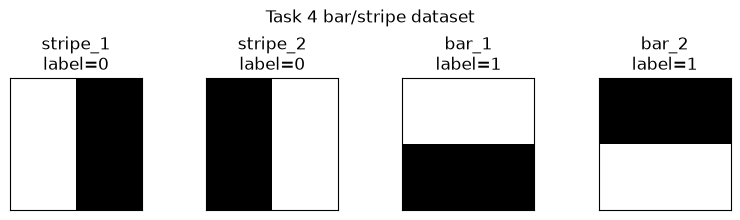

,p0,p1,p2,p3
stripe_1,1.0,0.0,1.0,0.0
stripe_2,0.0,1.0,0.0,1.0
bar_1,1.0,1.0,0.0,0.0
bar_2,0.0,0.0,1.0,1.0


In [2]:
image_data = generate_bar_stripe_data(side_length=2)
dataset = image_data.features
labels = image_data.labels

figure, axes = plt.subplots(1, len(dataset), figsize=(8, 2.2))
for axis, pixels, label, name in zip(
    axes, dataset, labels, image_data.names, strict=True
):
    axis.imshow(pixels.reshape(2, 2), cmap="gray", vmin=0, vmax=1)
    axis.set_title(f"{name}\nlabel={label}")
    axis.set_xticks([])
    axis.set_yticks([])
figure.suptitle("Task 4 bar/stripe dataset")
plt.tight_layout()
plt.show()

pd.DataFrame(dataset, index=image_data.names, columns=["p0", "p1", "p2", "p3"])

## 3. Deterministic starter split

The original 75/25 split was different on every run. A local
`numpy.random.Generator` seeded with 802 preserves the same split rule while
making the selected indices auditable. Because four samples yield only one
test sample, later effectiveness claims also report full-dataset and
leave-one-out measures; the single test item is not treated as a reliable
generalisation estimate.

In [3]:
split = deterministic_split(dataset, labels, seed=SEED)
training, training_labels = split.training, split.training_labels
test, test_labels = split.test, split.test_labels

print("Training indices:", split.training_indices.tolist())
print("Training labels:", training_labels.tolist())
print("Test indices:", split.test_indices.tolist())
print("Test labels:", test_labels.tolist())

assert split.training_indices.tolist() == [3, 0, 2]
assert split.test_indices.tolist() == [1]
assert set(training_labels) == {0, 1}
print("Deterministic split checks: PASS")

Training indices: [3, 0, 2]
Training labels: [1, 0, 1]
Test indices: [1]
Test labels: [0]
Deterministic split checks: PASS


## 4. Circuit and input analysis

### 4.1 Problem formulation and exact data-input location

The problem is binary image classification: vertical stripe patterns have
target 0 and horizontal bar patterns target 1. A sample is the flattened vector
$x=(x_0,x_1,x_2,x_3)$ in row-major pixel order. The **data enters only in the
basis-encoding loop**:

```python
for qubit, pixel in enumerate(sample):
    if pixel > 0.5:
        circuit.x(qubit)
```

Thus pixel $x_i=1$ prepares qubit $q_i$ in $|1\rangle$; a zero leaves it in
$|0\rangle$. The six angles are trainable model parameters, not data inputs.
Qiskit's displayed bit order does not change this index mapping.

In [4]:
from mse802.quantum_ml import (
    create_quantum_classifier_circuit,
    exact_output_probability,
    generate_pairs,
    parameter_count,
)

N_QUBITS = dataset.shape[1]
N_PARAMETERS = parameter_count(N_QUBITS)
PAIR_SCHEDULE = generate_pairs(N_QUBITS)

print("Qubit/pixel mapping:", {f"p{i}": f"q{i}" for i in range(N_QUBITS)})
print("Recursive pairs:", PAIR_SCHEDULE)
print("Trainable parameters:", N_PARAMETERS)
print("Readout: q3 -> c0")

Qubit/pixel mapping: {'p0': 'q0', 'p1': 'q1', 'p2': 'q2', 'p3': 'q3'}
Recursive pairs: ((0, 1), (2, 3), (1, 3))
Trainable parameters: 6
Readout: q3 -> c0


### 4.2 Recursive RY–RY–CX model

Each pair $(i,j)$ receives $R_Y(\theta_k)$ on $q_i$,
$R_Y(\theta_{k+1})$ on $q_j$, then CNOT with $q_i$ as control and $q_j$ as
target. For four qubits the post-order recursion produces:

1. $(q_0,q_1)$ — combine the first two pixels;
2. $(q_2,q_3)$ — combine the last two pixels; and
3. $(q_1,q_3)$ — combine the two branches into output qubit $q_3$.

There are $n-1=3$ blocks and therefore $2(n-1)=6$ angles. RY can create
superposition from basis inputs; subsequent CNOTs can then create
entanglement. Only $q_3$ is measured into the one-bit classical register, so
the model prediction is $P(c_0=1)$.

**Figure 2.** Four-qubit basis encoder and recursive RY–RY–CX classifier.

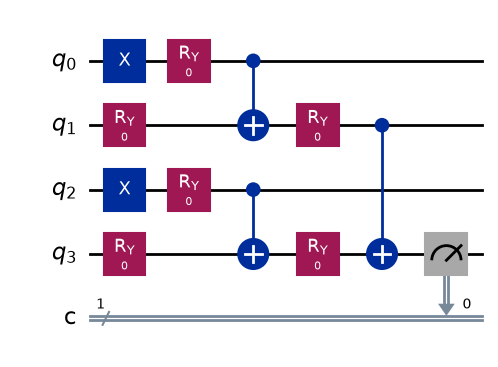

       ┌───┐  ┌───────┐                      
q_0: ──┤ X ├──┤ Ry(0) ├──■───────────────────
     ┌─┴───┴─┐└───────┘┌─┴─┐┌───────┐        
q_1: ┤ Ry(0) ├─────────┤ X ├┤ Ry(0) ├──■─────
     └─┬───┬─┘┌───────┐└───┘└───────┘  │     
q_2: ──┤ X ├──┤ Ry(0) ├──■─────────────┼─────
     ┌─┴───┴─┐└───────┘┌─┴─┐┌───────┐┌─┴─┐┌─┐
q_3: ┤ Ry(0) ├─────────┤ X ├┤ Ry(0) ├┤ X ├┤M├
     └───────┘         └───┘└───────┘└───┘└╥┘
c: 1/══════════════════════════════════════╩═
                                           0 
Exact P(output=1) at zero angles: [0. 0. 0. 0.]


In [5]:
zero_angles = np.zeros(N_PARAMETERS)
example_circuit = create_quantum_classifier_circuit(dataset[0], zero_angles)
display(example_circuit.draw("mpl", fold=30))
print(example_circuit)

zero_predictions = np.array(
    [exact_output_probability(sample, zero_angles) for sample in dataset]
)
print("Exact P(output=1) at zero angles:", zero_predictions)
assert np.allclose(zero_predictions, 0.0, atol=1e-12)

### 4.3 Zero-angle diagnostic

With every RY angle zero, the three CNOTs form a parity tree and $q_3$ holds
$x_0\oplus x_1\oplus x_2\oplus x_3$. Every supplied image contains exactly
two white pixels, so all four outputs are 0. This correctly proves that the
untrained model cannot distinguish the classes; non-zero learned rotations are
essential. The exact statevector calculation avoids confusing shot noise with
model behaviour.

## 5. Switchable quantum backend

One circuit constructor feeds three execution modes:

- **exact** — statevector $P(c_0=1)$, with no shots;
- **aer** — local shot-based execution with an explicit simulator seed; and
- **quokka** — the same OpenQASM subset submitted to the configured endpoint.

Optimization uses Aer locally. A fixed six-angle vector is evaluated separately
on the exact statevector, Aer, and real Quokka so backend validation does not
multiply the number of remote optimizer calls. The captured response is saved
with endpoint, timestamp, QASM, counts, and raw payload.

In [6]:
import json

from mse802.quantum_ml import execute_quantum_classifier

FIXED_VALIDATION_ANGLES = np.array([0.2, -0.4, 0.6, 0.8, -0.3, 0.5])
backend_evidence = json.loads(
    (ROOT / "submission" / "Task_4_Quantum_ML" /
     "task4_backend_validation.json").read_text()
)

backend_rows = []
for index, (sample, name) in enumerate(zip(dataset, image_data.names, strict=True)):
    exact = execute_quantum_classifier(
        sample, FIXED_VALIDATION_ANGLES, backend="exact"
    )
    aer = execute_quantum_classifier(
        sample,
        FIXED_VALIDATION_ANGLES,
        backend="aer",
        shots=256,
        seed=SEED + index,
    )
    remote = backend_evidence["records"][index]["quokka"]
    backend_rows.append(
        {
            "sample": name,
            "exact P(1)": exact.probability_one,
            "Aer P(1)": aer.probability_one,
            "Quokka P(1)": remote["probability_one"],
            "|Aer-Quokka|": abs(
                aer.probability_one - remote["probability_one"]
            ),
        }
    )

pd.DataFrame(backend_rows)

,sample,exact P(1),Aer P(1),Quokka P(1),|Aer-Quokka|
0,stripe_1,0.085289,0.085938,0.097656,0.011719
1,stripe_2,0.439952,0.449219,0.460938,0.011719
2,bar_1,0.421458,0.417969,0.421875,0.003906
3,bar_2,0.182941,0.207031,0.191406,0.015625


The fixed-vector comparison is a backend check, not evidence of training
quality. Exact and Aer results should differ only by finite-shot sampling.
Any larger systematic Quokka difference is reported rather than silently
replacing the remote result; optimization and the classical benchmark remain
locally reproducible.

In the captured run, the largest absolute Aer–Quokka probability difference
across the four samples is **0.015625** (four counts out of 256). This is small
relative to the sampling uncertainty and provides no evidence of a systematic
backend disagreement for this circuit.

## 6. Optimization trace

The objective is retained from the starter notebook:

$$
\operatorname{MAE}(\theta)
=\frac{1}{N}\sum_i\left|P_\theta(c_0=1\mid x_i)-y_i\right|.
$$

The supplied SPSA approach is run for 60 updates on local Aer at 256 shots per
circuit. A fixed random seed provides the same perturbations and the same
per-sample simulator streams on every clean execution. Each update evaluates
the positive perturbation, negative perturbation, and updated point. The trace
also contains iteration 0 so improvement from the initial point is visible.
Wall time is measured with a monotonic high-resolution clock; its exact value
is machine-dependent.

**Figures 3 and 4.** Training MAE and cumulative elapsed time across the saved
SPSA trace.

In [7]:
optimization = json.loads(
    (ROOT / "submission" / "Task_4_Quantum_ML" /
     "task4_quantum_optimization.json").read_text()
)
trace = pd.read_csv(
    ROOT / "submission" / "Task_4_Quantum_ML" /
    "task4_quantum_optimization_trace.csv"
)

assert trace["iteration"].tolist() == list(range(61))
assert trace["elapsed_seconds"].is_monotonic_increasing
print(
    f"Initial MAE: {optimization['initial_objective_mae']:.4f}\n"
    f"Final MAE:   {optimization['final_objective_mae']:.4f}\n"
    f"Best MAE:    {optimization['best_objective_mae']:.4f} "
    f"(iteration {optimization['best_iteration']})\n"
    f"Circuits:    {optimization['circuit_executions']}\n"
    f"Total shots: {optimization['total_shots']:,}\n"
    f"Wall time:   {optimization['elapsed_seconds']:.3f} s"
)

Initial MAE: 0.5638
Final MAE:   0.2904
Best MAE:    0.2904 (iteration 60)
Circuits:    543
Total shots: 139,008
Wall time:   1.430 s


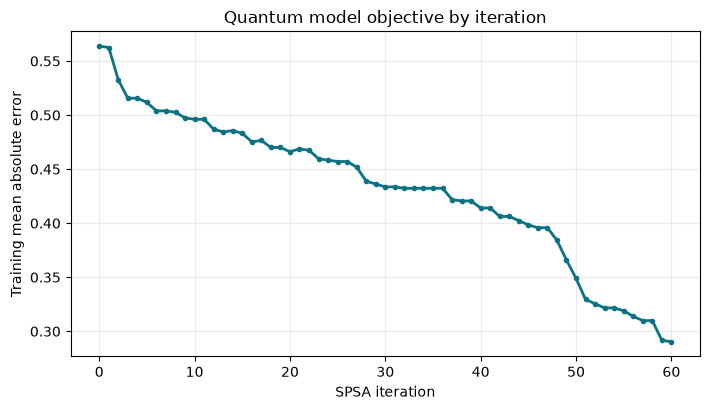

In [8]:
figure, axis = plt.subplots(figsize=(7.2, 4.2))
axis.plot(
    trace["iteration"],
    trace["objective_mae"],
    color="#0B7285",
    linewidth=2,
    marker="o",
    markersize=3,
)
axis.set(
    xlabel="SPSA iteration",
    ylabel="Training mean absolute error",
    title="Quantum model objective by iteration",
)
axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

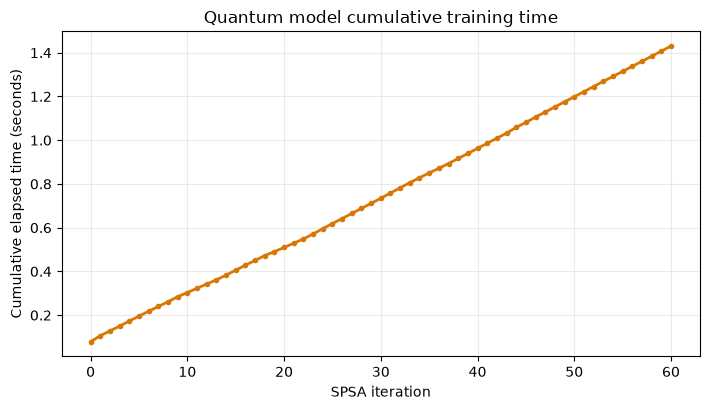

In [9]:
figure, axis = plt.subplots(figsize=(7.2, 4.2))
axis.plot(
    trace["iteration"],
    trace["elapsed_seconds"],
    color="#D97706",
    linewidth=2,
    marker="o",
    markersize=3,
)
axis.set(
    xlabel="SPSA iteration",
    ylabel="Cumulative elapsed time (seconds)",
    title="Quantum model cumulative training time",
)
axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

The metric need not decrease monotonically: SPSA estimates a direction
from simultaneous finite perturbations, and the circuit output is sampled.
Therefore the initial, final, and best recorded values are all retained rather
than showing only a favourable point. Resource counts include every objective
evaluation used by the optimizer.

## 7. Classical no-circuit baseline

A completely separate module computes two ordinary numeric features from each
2×2 image:

- mean change between rows (`vertical_change`); and
- mean change between columns (`horizontal_change`).

Vertical stripe images become `[0, 1]`, while horizontal bars become `[1, 0]`.
A balanced logistic-regression model is fitted on the same three training
indices as the quantum model. This path uses NumPy and scikit-learn only: it
creates no QASM, quantum circuit, simulator job, remote request, or shots.

In [10]:
from mse802.classical_ml import (
    fit_classical_orientation_classifier,
    orientation_features,
    predict_classical_orientation_classifier,
)

classical_fit = fit_classical_orientation_classifier(
    training,
    training_labels,
    side_length=image_data.side_length,
)
classical_prediction = predict_classical_orientation_classifier(
    classical_fit,
    dataset,
)
classical_evidence = json.loads(
    (ROOT / "submission" / "Task_4_Quantum_ML" /
     "task4_classical_baseline.json").read_text()
)

classical_table = pd.DataFrame(
    {
        "sample": image_data.names,
        "label": labels,
        "vertical change": orientation_features(dataset)[:, 0],
        "horizontal change": orientation_features(dataset)[:, 1],
        "P(class=1)": classical_prediction.probability_one,
        "prediction": classical_prediction.labels,
    }
)
display(classical_table)
print(
    f"Saved full-dataset accuracy: "
    f"{classical_evidence['full_dataset']['accuracy']:.3f}\n"
    f"Saved full-dataset MAE: "
    f"{classical_evidence['full_dataset']['mean_absolute_error']:.4f}\n"
    f"Quantum circuits/shots: "
    f"{classical_evidence['quantum_circuits']}/"
    f"{classical_evidence['quantum_shots']}"
)
assert classical_prediction.labels.tolist() == labels.tolist()
assert classical_evidence["quantum_circuits"] == 0
assert classical_evidence["quantum_shots"] == 0

,sample,label,vertical change,horizontal change,P(class=1),prediction
0,stripe_1,0,0.0,1.0,0.024589,0
1,stripe_2,0,0.0,1.0,0.024589,0
2,bar_1,1,1.0,0.0,0.975411,1
3,bar_2,1,1.0,0.0,0.975411,1


Saved full-dataset accuracy: 1.000
Saved full-dataset MAE: 0.0246
Quantum circuits/shots: 0/0


## 8. Results, limitations, and conclusion

Both models use the seed-802 split and a probability threshold of 0.5. The
table and four-panel figure compare training/test/full-dataset accuracy and
MAE, plus measured training and four-sample inference time. Timing is local
wall-clock time; seven warmed inference runs are summarized by their median.

**Figure 5.** Quantum and classical effectiveness and efficiency comparison.

,model,training_seconds,full_inference_median_seconds,training_accuracy,training_mean_absolute_error,test_accuracy,test_mean_absolute_error,full_accuracy,full_mean_absolute_error
0,quantum,1.430195,0.009974,1.0,0.290365,1.0,0.265625,1.0,0.275391
1,classical,0.046609,0.000994,1.0,0.024589,1.0,0.024589,1.0,0.024589


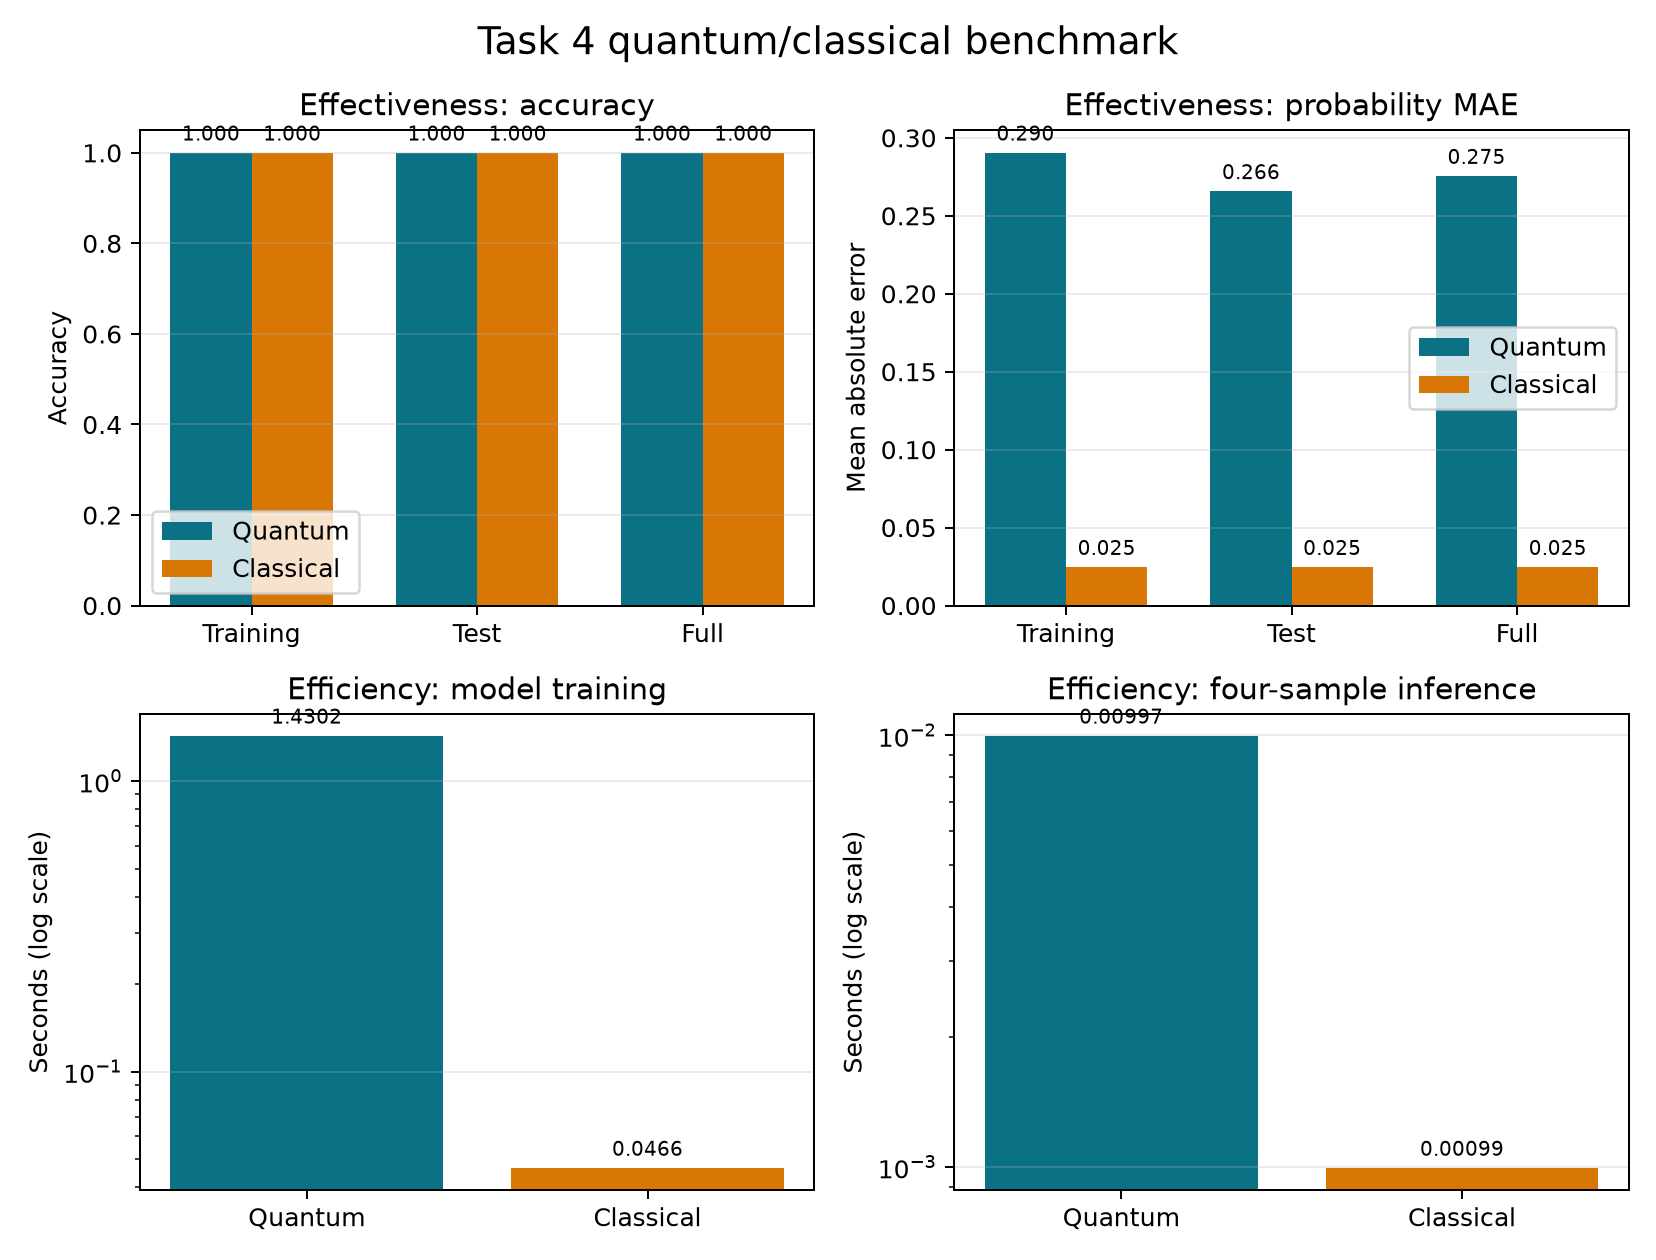

In [11]:
benchmark = json.loads(
    (ROOT / "submission" / "Task_4_Quantum_ML" /
     "task4_quantum_classical_benchmark.json").read_text()
)
benchmark_table = pd.read_csv(
    ROOT / "submission" / "Task_4_Quantum_ML" /
    "task4_quantum_classical_benchmark.csv"
)
display(benchmark_table)

from IPython.display import Image, display

display(
    Image(
        filename=str(
            ROOT / "submission" / "Task_4_Quantum_ML" /
            "task4_quantum_classical_comparison.png"
        )
    )
)

### 8.1 Effectiveness

At the shared 0.5 threshold, both models classify all three training samples,
the one held-out sample, and all four supplied samples correctly. Accuracy
therefore ties at 1.0. Probability MAE distinguishes confidence: the classical
orientation model is closer to its target labels than the trained quantum
model on this dataset.

### 8.2 Efficiency

Quantum optimization executed **543 circuits / 139,008 shots** before final
evaluation. One full-dataset quantum inference requires four more circuits and
1,024 shots. The classical model fits and predicts with vector/matrix
operations and uses **zero quantum circuits and zero shots**. On this local
machine it is faster for both training and inference; exact timing ratios are
read from the retained benchmark because wall time is hardware-dependent.

### 8.3 Limitations and conclusion

Only four generated images exist and the deterministic test set contains one
stripe. Moreover, the two engineered classical features directly encode the
bar/stripe generation rule. Consequently:

- 100% test accuracy is one correct decision, not a reliable generalisation
  estimate;
- the result demonstrates two functioning pipelines, not quantum advantage;
- Aer timing excludes remote queue/network latency, while Quokka was used only
  for fixed-parameter backend validation; and
- broader images, more samples, repeated splits, and uncertainty intervals
  would be needed for a substantive model comparison.

For this narrowly defined 2×2 task, the classical version is both more
resource-efficient and more confident, while the quantum version usefully
demonstrates basis encoding, a trainable RY–CX tree, sampled optimization, and
portable execution across Aer and Quokka.

## References

[1] MSE802 Quantum Computing, “Quantum machine-learning assessment starter notebook,” course material, 2026.

[2] IBM Quantum, “Quantum circuit model,” 2026. [Online]. Available: https://quantum.cloud.ibm.com/docs/api/qiskit/circuit (accessed 24 July 2026).

[3] IBM Quantum, “RYGate,” 2026. [Online]. Available: https://quantum.cloud.ibm.com/docs/api/qiskit/1.3/qiskit.circuit.library.RYGate (accessed 24 July 2026).

[4] IBM Quantum, “Bit ordering in Qiskit,” 2026. [Online]. Available: https://quantum.cloud.ibm.com/docs/en/guides/bit-ordering (accessed 24 July 2026).

[5] Qiskit Aer, “AerSimulator,” 2026. [Online]. Available: https://qiskit.github.io/qiskit-aer/stubs/qiskit_aer.AerSimulator.html (accessed 24 July 2026).

[6] J. C. Spall, “Multivariate stochastic approximation using a simultaneous perturbation gradient approximation,” *IEEE Transactions on Automatic Control*, vol. 37, no. 3, pp. 332–341, 1992. [Online]. Available: https://www.jhuapl.edu/spsa/pdf-spsa/spall_tac92.pdf (accessed 24 July 2026).

[7] scikit-learn, “LogisticRegression,” 2026. [Online]. Available: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html (accessed 24 July 2026).